# Assignment A

In this notebook, I explore the loan approval dataset. The goal is to understand which features help predict the **approval/rejection** of a person's loan.

### Sections
1. **Loading the data**
<br>Import necessary libraries, load CSV file, and print first 20 rows.

2. **Exploring the dataset**
<br>Check size, data types, missing values & duplicates. Also check distribution of target variable 'loan_status'.

3. **Feature importance table**
<br>Decide whether each column is *important*, *in-between*, or *not-important* for predicting the target 'loan_status'.

4. **Correlation heatmap**
<br>Calculate the correlations between the numeric features with '.corr()', store them in 'corrmatrix', and plot them with 'sns.heatmap()'.

5. **Effect of features on loan status**
<br>Relationship between numeric & categorical features to target 'loan_status'.

## Section 1 - Loading the Data

In [1]:
# Import all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [2]:
# Print the file in the Kaggle input folder to gain access to exact path
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/evapetrovska/loan-approval-dataset/loan_approval_dataset.csv


In [3]:
# Assign the path
path = "/kaggle/input/datasets/evapetrovska/loan-approval-dataset/loan_approval_dataset.csv"

# File uses ";" as separator + a space
# Read the CSV using the separator and deleting the space
df = pd.read_csv(path, sep=";", skipinitialspace=True)

# Display all columns in the output
pd.set_option("display.max_columns", None) # None prevents Kaggle from limiting number of columns being displayed

# Print shape and first 20 rows
print("Shape of dataset:",df.shape)
print("=" * 100)
print("First 20 rows:")
df.head(20)

Shape of dataset: (4269, 13)
First 20 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


## Section 2 - Exploring the Data

In [4]:
# Build one summary table displaying data types and count of null values
summary = pd.DataFrame({
    "Data type": df.dtypes, # Column 1 - data types
    "Missing values": df.isna().sum(), # Column 2 - missing values
    "Unique values": df.nunique() # Column 3 - unique values
})

# Display the number of rows, columns, and duplicate rows
print("Dataset Overview")
print("=" * 100)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

# Display the results formatted as a table
summary

Dataset Overview
Rows: 4269
Columns: 13
Duplicate rows: 0


,Data type,Missing values,Unique values
loan_id,int64,0,4269
no_of_dependents,int64,0,6
education,object,0,2
self_employed,object,0,2
income_annum,int64,0,98
loan_amount,int64,0,378
loan_term,int64,0,10
cibil_score,int64,0,601
residential_assets_value,int64,0,278
commercial_assets_value,int64,0,188


In [5]:
# Summary statistics
# Apply numerical statistics to the dataset - mean, standard deviation, minimum, maximum, and quartiles
print("Summary Statistics Chart")
print("=" * 100)
df.describe().T # T flips the columns as rows for better readability

Summary Statistics Chart


,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


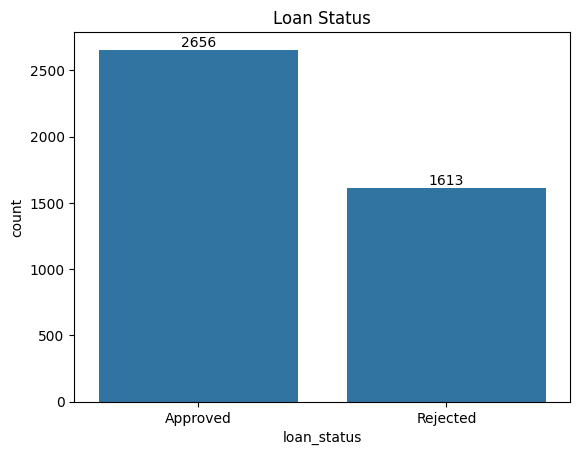

In [6]:
# Loan status plot
# Depicts the number of 'approved' and 'rejected' loans

# Count of each class
print(df["loan_status"].value_counts())

# Bar chart of the two classes
print("=" * 100)
ax = sns.countplot(data=df, x="loan_status") # Bar chart of the two classes
ax.bar_label(ax.containers[0]) # Labels on top of the chart
plt.title("Loan Status")
plt.show()

## Section 3 - Feature Importance

Before calculating any correlations, I need to determine the importance of each feature to the target **loan_status**.
The table representation goes as follows.

| Feature | Important | In-Between | Not Important | Reason |
|---|:---:|:---:|:---:|---|
| `loan_id` | | | ✓ | Just a row number, it says nothing about the person. |
| `no_of_dependents` | | ✓ | | More dependents means more expenses, so less money left to repay the loan. |
| `education` | | ✓ | | A degree may mean a more stable job, but does not directly show ability to pay. |
| `self_employed` | | ✓ | | Self-employed income might be less stable, adding some risk. |
| `income_annum` | ✓ | | | Higher income means more money available to repay the loan. |
| `loan_amount` | ✓ | | | A bigger loan is riskier for the bank, especially compared to income. |
| `loan_term` | | ✓ | | A longer term lowers monthly payments, but the bank waits longer to get its money back. |
| `cibil_score` | ✓ | | | The credit score shows the person's history of repaying debts. Banks rely on it heavily. |
| `residential_assets_value` | | ✓ | | A house can act as security, but it is slow and hard to sell. |
| `commercial_assets_value` | | ✓ | | Business property adds security, but its value can change. |
| `luxury_assets_value` | | | ✓ | Cars, jewelry etc. lose value quickly and are not a reliable sign of repayment. |
| `bank_asset_value` | ✓ | | | Money in the bank can be used directly to repay the loan. 

## Section 4 - Correlation Heatmap

In [7]:
# Convert the loan_status target into 0/1 numeric
# Must do this to use .corr() on it
# approved = 1, rejected = 0
df["loan_status_num"] = df["loan_status"].map(
    {"Approved": 1, "Rejected": 0}
)

# Keep only the numeric columns (drop loan_id since it doesn't add any substance)
numeric_df = df.select_dtypes(include="number")
numeric_df = numeric_df.drop(columns=["loan_id"])

# Calculate correlation matrix
corrmatrix = numeric_df.corr()

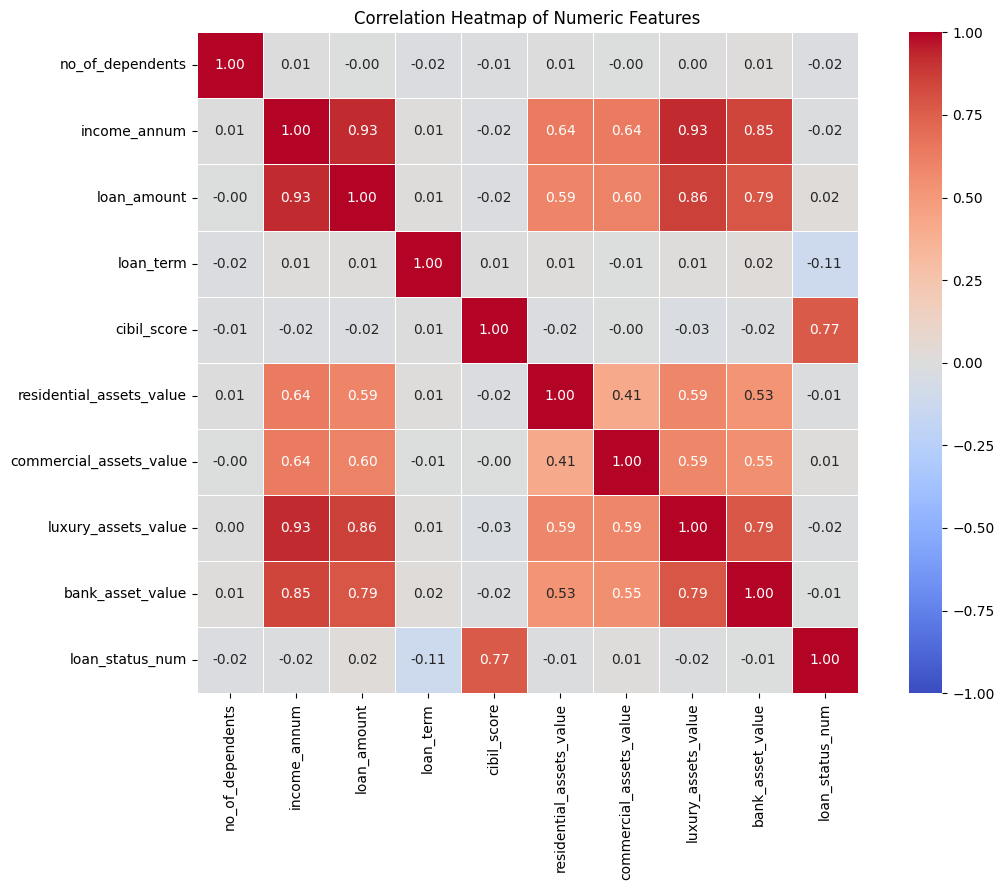

In [8]:
# Plot the actual heatmap
plt.figure(figsize=(12,9))

sns.heatmap(
    corrmatrix, # pass the matrix
    annot=True, # write the numbers in each square
    fmt=".2f", # round to 2 decimal places
    cmap="coolwarm", # color (red is positive, blue is negative)
    vmin=-1, # fix color scale
    vmax=1, # range from -1 to 1
    square=True, # make cells square
    linewidth=0.5 # lines between cells
    
)

# Characteristics of the heatmap
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## Section 5 - Effect of Features on Loan Status

In [9]:
# Map the categorical variable (education) with target loan_status
# Use contingency table
edu_table = pd.crosstab(
    df["education"], # education feature
    df["loan_status"], # loan_status feature
    normalize="index" # turns each row into proportions of 1
)

# Print table in percentages and round values
print("Contingency Table - Education & Loan Status")
print("=" * 100)
print((edu_table*100).round(2))

Contingency Table - Education & Loan Status
loan_status   Approved  Rejected
education                       
Graduate         62.45     37.55
Not Graduate     61.98     38.02


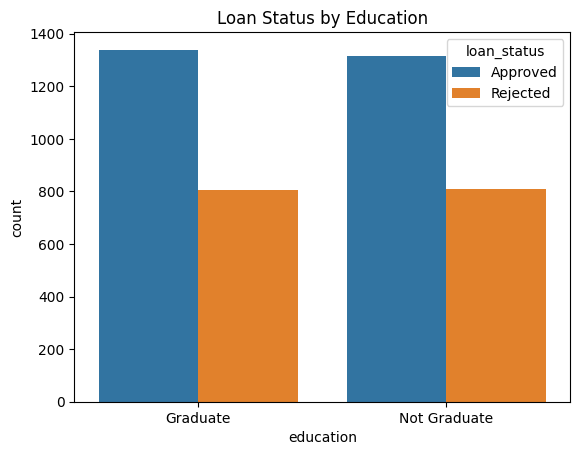

In [10]:
# Visualize the data - bar graph
sns.countplot(data=df, x="education", hue="loan_status")
plt.title("Loan Status by Education")
plt.show()

In [11]:
# Chi-square test - is education related to loan_status
counts = pd.crosstab(df["education"], df["loan_status"])
chi2, p_value, dof, expected = stats.chi2_contingency(counts)

# Print the chi2
print("Chi-Square & P-Value of Education & Loan Status")
print("=" * 100)
print("Chi-square:", round(chi2,3))
print("P-value:", round(p_value, 3))

Chi-Square & P-Value of Education & Loan Status
Chi-square: 0.084
P-value: 0.772
